notebooks/05_cohort_retention.py
==================================
Cohort retention analysis and heatmap.

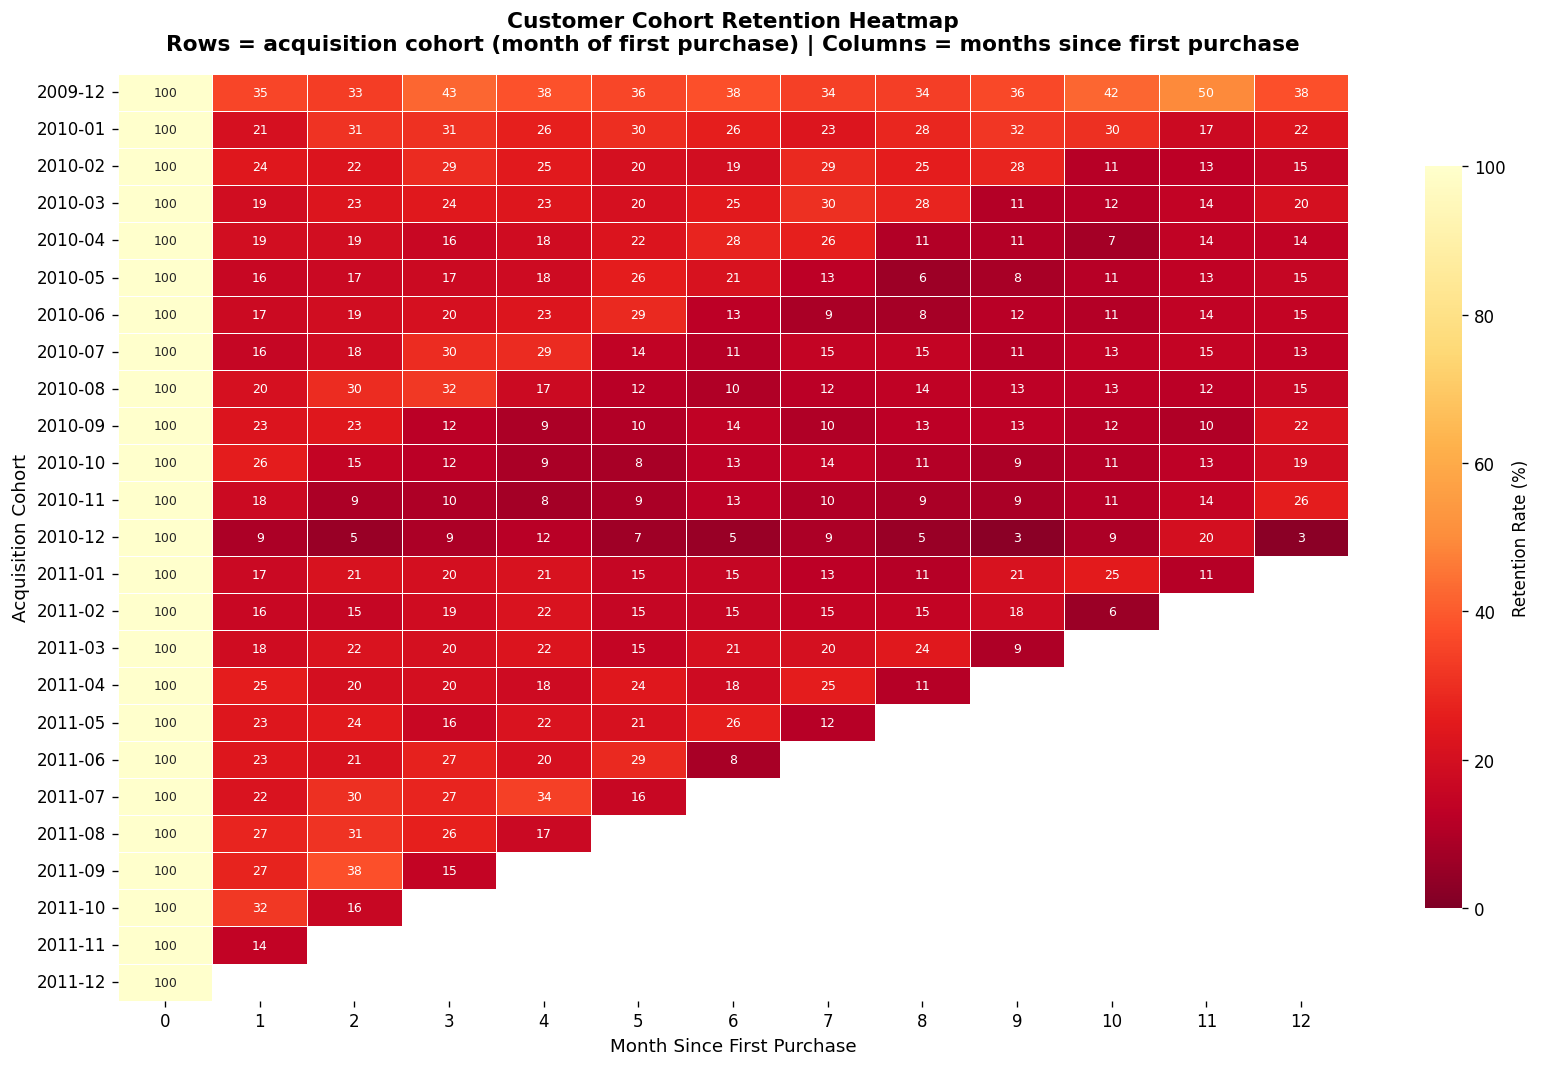

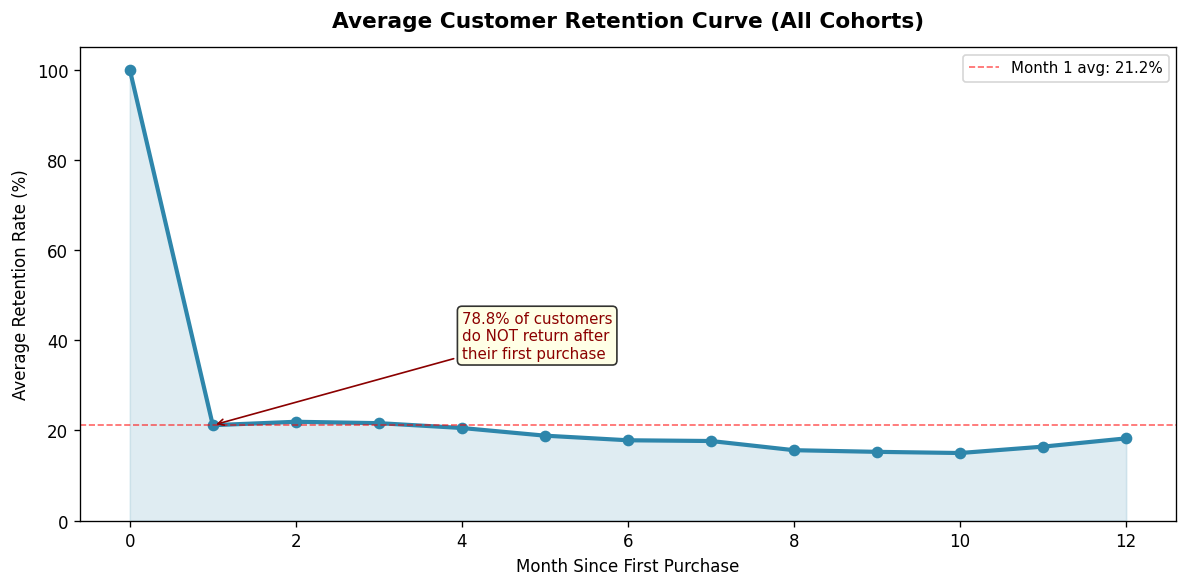

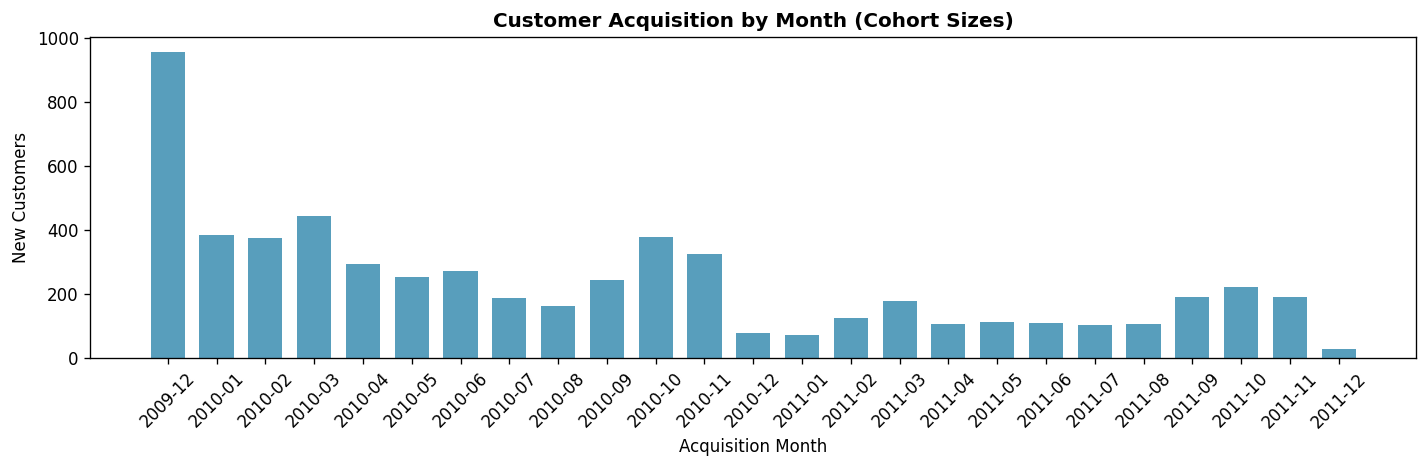

In [ ]:
import sys, os, matplotlib
matplotlib.use('Agg')
from pathlib import Path
_PROJECT_ROOT = Path(__file__).resolve().parent.parent
sys.path.insert(0, str(_PROJECT_ROOT))
os.chdir(_PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "font.family": "sans-serif",
})
FIGURES_DIR = _PROJECT_ROOT / "data" / "processed" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

from src.data_cleaning import load_cleaned
from src.cohort import run_cohort_pipeline, build_cohort_matrix

df = load_cleaned()
retention_pct, cohort_sizes = run_cohort_pipeline(df)

# Reload with period index for plotting
ret_plot, sizes = build_cohort_matrix(df)

# ── Chart 1: Full cohort retention heatmap ────────────────────────────────────
# Cap columns to first 13 months (one year + 1) for readability
n_cols = min(13, ret_plot.shape[1])
ret_plot_trimmed = ret_plot.iloc[:, :n_cols]

# Format index as strings for display
ret_plot_trimmed.index = ret_plot_trimmed.index.astype(str)

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(
    ret_plot_trimmed,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd_r",       # reversed: darker = higher retention (better)
    linewidths=0.4,
    linecolor="white",
    ax=ax,
    vmin=0, vmax=100,
    cbar_kws={"label": "Retention Rate (%)", "shrink": 0.8},
    annot_kws={"size": 7.5},
    mask=ret_plot_trimmed.isna(),   # don't annotate NaN cells (cohort hasn't reached that period)
)
ax.set_title(
    "Customer Cohort Retention Heatmap\n"
    "Rows = acquisition cohort (month of first purchase) | "
    "Columns = months since first purchase",
    fontsize=13, fontweight="bold", pad=14,
)
ax.set_xlabel("Month Since First Purchase", fontsize=11)
ax.set_ylabel("Acquisition Cohort", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "14_cohort_heatmap.png", bbox_inches="tight")
plt.close()
print("Saved: 14_cohort_heatmap.png")

# ── Chart 2: Average retention curve ─────────────────────────────────────────
avg_ret = ret_plot.mean(axis=0)
months = avg_ret.index.tolist()[:n_cols]
vals = avg_ret.values[:n_cols]

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(months, vals, alpha=0.15, color="#2E86AB")
ax.plot(months, vals, color="#2E86AB", linewidth=2.5, marker="o", markersize=6)
ax.set_title("Average Customer Retention Curve (All Cohorts)", fontsize=13,
             fontweight="bold", pad=12)
ax.set_xlabel("Month Since First Purchase")
ax.set_ylabel("Average Retention Rate (%)")
ax.set_ylim(0, 105)
ax.axhline(y=vals[1] if len(vals) > 1 else 20, color="red", linestyle="--",
           linewidth=1, alpha=0.6, label=f"Month 1 avg: {vals[1]:.1f}%")

# Annotate the big drop
if len(vals) > 1:
    ax.annotate(
        f"78.8% of customers\ndo NOT return after\ntheir first purchase",
        xy=(1, vals[1]),
        xytext=(4, vals[1] + 15),
        arrowprops=dict(arrowstyle="->", color="darkred"),
        fontsize=9, color="darkred",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8),
    )
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "15_retention_curve.png", bbox_inches="tight")
plt.close()
print("Saved: 15_retention_curve.png")

# ── Chart 3: Cohort size (how many customers acquired each month) ─────────────
sizes_df = sizes.reset_index()
sizes_df.columns = ["CohortMonth", "Customers"]
sizes_df["CohortMonth_str"] = sizes_df["CohortMonth"].astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(sizes_df["CohortMonth_str"], sizes_df["Customers"],
       color="#2E86AB", alpha=0.8, width=0.7)
ax.set_title("Customer Acquisition by Month (Cohort Sizes)", fontsize=12, fontweight="bold")
ax.set_xlabel("Acquisition Month")
ax.set_ylabel("New Customers")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "16_cohort_sizes.png", bbox_inches="tight")
plt.close()
print("Saved: 16_cohort_sizes.png")

print("\nCohort retention notebook complete.")
print("\n--- KEY FINDING ---")
print("Only 21.2% of customers make a second purchase (Month 1 retention).")
print("This is the single biggest growth lever: improving first-to-second")
print("purchase conversion from 21% to 30% would add ~500 retained customers/year.")